# char_08 — Which *kind* of charcoal? Fire-produced vs furnace, woody vs herbaceous

## Purpose — and a gap in the earlier notebooks

`char_02` matched Addis against a pooled "charcoal library" of 3,924 spectra. That
library was built by filtering on a known pyrolysis temperature, and that filter had a
consequence never stated at the time:

> **The 1,934 Minatre combustion-facility spectra were excluded from every comparison in
> `char_02` and `char_04`.** They carry no temperature label — they are instrumented
> *open burns* — so `temp_c.notna()` dropped them silently.

That is arguably the wrong set to drop. Furnace charcoal is made by heating wood in a
muffle at a controlled temperature; combustion-facility charcoal is recovered from actual
vegetation fires. If the goal is an analogue for biomass-burning aerosol at Addis, the
fire-produced material is the more relevant reference, and it had never been tested.

`char_05`–`char_07` narrowed the reference set further still — to McCall's 216 ATR
biochar spectra — so no woody charcoal in the Minatre sense entered those either.

This notebook closes both gaps:

1. Does **fire-produced** char match Addis better than **furnace** charcoal?
2. Does **woody** char match better than **herbaceous** char?
3. Does either change the dry-season picture from `char_06`?

## Scope: charcoal is not soot

Everything in this archive is **char** — carbonized solid fuel, formed within the fuel
particle. Atmospheric black carbon is largely **soot**, formed by gas-phase nucleation in
the flame, and it is a chemically and structurally different material. No collection here
contains wood-smoke soot, diesel soot, or a standardized black-carbon reference. That is
a hard limit on what any notebook in this folder can conclude, and it is restated in the
takeaways.

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats

from charcoal_spectra import (
    load_all, snv, resample, detrend, prepare, prepare_shape, shape_norm, ramp_score,
)
from etad_spectra import load_etad

PLOT_DIR = Path("output/plots/char08")
TABLE_DIR = Path("output/tables/char08")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#e34948"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"

SEASON_COLORS = {
    "Dry Season": "#E67E22",
    "Belg Rainy Season": "#27AE60",
    "Kiremt Rainy Season": "#3498DB",
}
SEASON_MAP = {
    "Dry (Oct-Feb)": "Dry Season",
    "Belg (Mar-May)": "Belg Rainy Season",
    "Kiremt (Jun-Sep)": "Kiremt Rainy Season",
}

ADDIS_PREP = ("Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
              "→ linear detrend → SNV   ·   charcoal: as published → detrend → SNV")


def stamp(fig, text=ADDIS_PREP):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)


GRID = np.arange(1430.0, 3500.0 + 1e-9, 2.0)

# McCall feedstocks that are woody tissue rather than grass or husk.
WOODY = {"chestnut wood", "eucalyptus bark", "pine bark"}

## Define the reference classes

Seven classes, including the two that previous notebooks never used: the
combustion-facility burns and the Ayauchi fossil charcoal.

In [2]:
sets = load_all()


def prep(X, wn):
    return snv(detrend(resample(X, wn, GRID), GRID))


def prep_s(X, wn):
    # Companion (unit-area) form, used only in the overlay's companion figure.
    return shape_norm(detrend(resample(X, wn, GRID), GRID), GRID)


classes = {}

mr = sets["minatre_ref"]
classes["Minatre woody charcoal (furnace, 200–800 °C)"] = prep(mr.X, mr.wn)

mb = sets["minatre_burn"]
classes["Minatre combustion-facility char (real fires)"] = prep(mb.X, mb.wn)

mm = sets["mccall_multi"]
Xmm, mmm = prep(mm.X, mm.wn), mm.meta
woody_m = (mmm["species"].isin(WOODY) & (mmm["temp_c"] > 0)).to_numpy()
herb_m = ((~mmm["species"].isin(WOODY)) & (mmm["temp_c"] > 0)).to_numpy()
classes["McCall woody char (ATR)"] = Xmm[woody_m]
classes["McCall herbaceous char (ATR)"] = Xmm[herb_m]

mz = sets["maezumi"]
classes["Maezumi charcoal (furnace, 200–700 °C)"] = prep(mz.X, mz.wn)

wd = sets["wdg"]
Xwd, wdm = prep(wd.X, wd.wn), wd.meta
classes["Gosling modern charcoal (furnace)"] = Xwd[wdm["temp_c"].notna().to_numpy()]
classes["Gosling Ayauchi fossil charcoal"] = Xwd[
    wdm["is_fossil"].fillna(False).to_numpy(bool)]

etad_meta, X_etad_base, wn_etad_b = load_etad(baselined=True)
X_addis = prepare(X_etad_base, wn_etad_b, GRID)
X_addis_shape = prepare_shape(X_etad_base, wn_etad_b, GRID)
season = etad_meta["season"].map(SEASON_MAP).to_numpy()

inv = pd.DataFrame([
    {"reference class": k, "n spectra": len(v),
     "in the char_02 library?": "NO — dropped by the temperature filter"
     if ("combustion-facility" in k or "fossil" in k) else "yes"}
    for k, v in classes.items()]).set_index("reference class")
display(inv)
print(f"\nAddis filters: {X_addis.shape[0]}")
print(f"spectra newly brought into the comparison: "
      f"{len(classes['Minatre combustion-facility char (real fires)']) + len(classes['Gosling Ayauchi fossil charcoal']):,}")

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


,n spectra,in the char_02 library?
reference class,,
"Minatre woody charcoal (furnace, 200–800 °C)",2100,yes
Minatre combustion-facility char (real fires),1934,NO — dropped by the temperature filter
McCall woody char (ATR),72,yes
McCall herbaceous char (ATR),72,yes
"Maezumi charcoal (furnace, 200–700 °C)",1260,yes
Gosling modern charcoal (furnace),324,yes
Gosling Ayauchi fossil charcoal,31,NO — dropped by the temperature filter



Addis filters: 239
spectra newly brought into the comparison: 1,965


## 1. Does fire-produced char match Addis better than furnace charcoal?

In [3]:
def zrows(X):
    return (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)


Za = zrows(X_addis)
best, meanr = {}, {}
for name, X in classes.items():
    R = (Za @ zrows(X).T) / GRID.size
    best[name] = R.max(axis=1)
    meanr[name] = R.mean(axis=1)

summary = pd.DataFrame({
    "n refs": {k: len(v) for k, v in classes.items()},
    "median best r": {k: np.median(v) for k, v in best.items()},
    "median mean r": {k: np.median(v) for k, v in meanr.items()},
}).sort_values("median best r", ascending=False)
display(summary.round(3))
summary.round(4).to_csv(TABLE_DIR / "reference_class_match.csv")

fur = best["Minatre woody charcoal (furnace, 200–800 °C)"]
fire = best["Minatre combustion-facility char (real fires)"]
w = stats.wilcoxon(fur, fire)
print(f"\nfurnace vs fire, paired over the same {len(fur)} filters:")
print(f"  median best r  {np.median(fur):.3f} (furnace)  vs  {np.median(fire):.3f} (fire)")
print(f"  Wilcoxon signed-rank p = {w.pvalue:.2e}")
print(f"  Addis filters better matched by fire-produced char: "
      f"{(fire > fur).sum()} of {len(fur)} ({(fire > fur).mean():.1%})")

,n refs,median best r,median mean r
"Minatre woody charcoal (furnace, 200–800 °C)",2100,0.777,0.474
"Maezumi charcoal (furnace, 200–700 °C)",1260,0.615,0.429
Gosling modern charcoal (furnace),324,0.586,0.403
Minatre combustion-facility char (real fires),1934,0.566,0.308
Gosling Ayauchi fossil charcoal,31,0.566,0.453
McCall herbaceous char (ATR),72,0.497,0.258
McCall woody char (ATR),72,0.430,0.272



furnace vs fire, paired over the same 239 filters:
  median best r  0.777 (furnace)  vs  0.566 (fire)
  Wilcoxon signed-rank p = 1.23e-40
  Addis filters better matched by fire-produced char: 1 of 239 (0.4%)


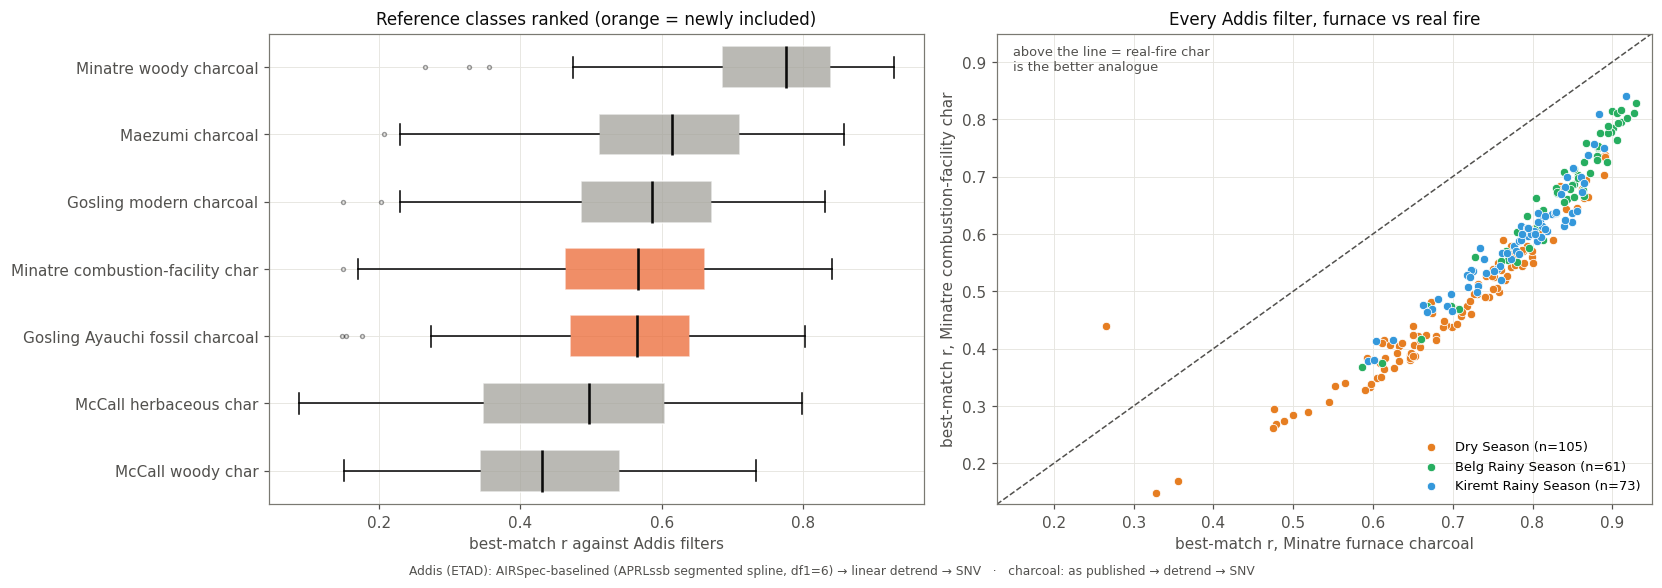

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

ax = axes[0]
order = summary.index.tolist()
bp = ax.boxplot([best[k] for k in order], vert=False,
                tick_labels=[k.split(" (")[0] for k in order],
                patch_artist=True, widths=0.62,
                medianprops=dict(color=INK, lw=1.7), flierprops=dict(ms=2.5, alpha=0.4))
for patch, k in zip(bp["boxes"], order):
    new = ("combustion-facility" in k) or ("fossil" in k)
    patch.set_facecolor(SERIES[1] if new else MUTED)
    patch.set_alpha(0.75)
    patch.set_edgecolor("white")
ax.set_xlabel("best-match r against Addis filters", color=INK2)
ax.set_title("Reference classes ranked (orange = newly included)", color=INK)
ax.invert_yaxis()

ax = axes[1]
for s, color in SEASON_COLORS.items():
    m = season == s
    ax.scatter(fur[m], fire[m], s=30, c=color, edgecolor="white", linewidth=0.5,
               label=f"{s} (n={m.sum()})", zorder=3)
lims = [min(fur.min(), fire.min()) - 0.02, max(fur.max(), fire.max()) + 0.02]
ax.plot(lims, lims, color=INK2, lw=1, ls="--", zorder=1)
ax.annotate("above the line = real-fire char\nis the better analogue",
            xy=(lims[0] + 0.02, lims[1] - 0.02), fontsize=8.5, color=INK2, va="top")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("best-match r, Minatre furnace charcoal", color=INK2)
ax.set_ylabel("best-match r, Minatre combustion-facility char", color=INK2)
ax.set_title("Every Addis filter, furnace vs real fire", color=INK)
ax.legend(fontsize=8.5, loc="lower right")

stamp(fig)
fig.savefig(PLOT_DIR / "01_reference_classes.png", dpi=160, bbox_inches="tight")
plt.show()

**The fire-produced char is the *worse* analogue, and not marginally** — exactly one of
the 239 filters is matched better by it than by furnace charcoal. That is the opposite of
what the provenance argument predicts, so the next section tests whether it is an
artifact.

## 2. Why? Two explanations, both testable

**(a) Quality.** The combustion-facility spectra are much weaker in absolute absorbance
than the furnace reference. If they were correspondingly noisier, the low correlation
would be a measurement artifact rather than a statement about the material.

**(b) Coverage.** "Best match among *n* references" rewards a **diverse** library. The
furnace set spans 10 species × 7 temperatures by design; the burn set is 4 species at
whatever temperatures those fires happened to reach. A diverse library has more chances
to contain something Addis-like, independent of provenance.

In [5]:
quality = []
for name, key in [("Minatre woody charcoal (furnace, 200–800 °C)", "minatre_ref"),
                  ("Minatre combustion-facility char (real fires)", "minatre_burn")]:
    X = classes[name]
    Z = zrows(X)
    idx = rng.choice(len(X), 400, replace=False)
    S = (Z[idx] @ Z[idx].T) / GRID.size
    iu = np.triu_indices(len(idx), 1)
    quality.append({
        "reference class": name.split(" (")[0],
        "native median absorbance": np.median(sets[key].X),
        "roughness (noise proxy)": np.median(np.std(np.diff(X, n=2, axis=1), axis=1)),
        "within-class coherence": np.median(S[iu]),
    })
qt = pd.DataFrame(quality).set_index("reference class").round(4)
display(qt)
qt.to_csv(TABLE_DIR / "reference_quality.csv")
print("(a) REJECTED: the fire char is no noisier and is MORE internally coherent than the")
print("    furnace set. It is a tight, well-measured, genuinely different material.\n")

Xfur = classes["Minatre woody charcoal (furnace, 200–800 °C)"]
n_burn = len(classes["Minatre combustion-facility char (real fires)"])

# Subsampling the furnace set to the burn set's size (1,934 of 2,100) removes only 8% and
# is no control at all. Sweep the size instead, so the coverage effect can be measured
# rather than asserted.
sweep = []
for n in [25, 50, 100, 250, 500, 1000, n_burn]:
    draws = [np.median(((Za @ zrows(Xfur[rng.choice(len(Xfur), n, replace=False)]).T)
                        / GRID.size).max(axis=1)) for _ in range(15)]
    sweep.append({"furnace refs used": n, "median best r": np.mean(draws),
                  "sd across draws": np.std(draws)})
sweep = pd.DataFrame(sweep).set_index("furnace refs used").round(3)
print(f"(b) coverage sweep — furnace subsampled to n references, 15 draws each:")
display(sweep)
print(f"    the burn set, with n={n_burn:,} references, reaches only "
      f"{np.median(fire):.3f}.")
print(f"    Even {sweep.index[0]} furnace spectra beat it "
      f"({sweep['median best r'].iloc[0]:.3f}), so library size explains none of the gap.")
sweep.to_csv(TABLE_DIR / "coverage_sweep.csv")

burn_species = set(sets["minatre_burn"].meta["species"].dropna().unique())
mr_meta = sets["minatre_ref"].meta
same_sp = mr_meta["species"].isin(burn_species).to_numpy()
r_same = ((Za @ zrows(Xfur[same_sp]).T) / GRID.size).max(axis=1)
shared = sorted(burn_species & set(mr_meta["species"].dropna()))
print(f"\n    furnace restricted to the burn set's own species ({', '.join(shared)}; "
      f"n={same_sp.sum():,}):")
print(f"    median best r = {np.median(r_same):.3f}")
print("\n    Neither control closes the gap — the difference is the material, not the")
print("    library size or the species list.")

,native median absorbance,roughness (noise proxy),within-class coherence
reference class,,,
Minatre woody charcoal,0.1665,0.0138,0.7679
Minatre combustion-facility char,0.0597,0.0131,0.8164


(a) REJECTED: the fire char is no noisier and is MORE internally coherent than the
    furnace set. It is a tight, well-measured, genuinely different material.



(b) coverage sweep — furnace subsampled to n references, 15 draws each:


,median best r,sd across draws
furnace refs used,,
25,0.680,0.022
50,0.696,0.015
100,0.715,0.023
250,0.737,0.022
500,0.738,0.018
1000,0.752,0.019
1934,0.774,0.009


    the burn set, with n=1,934 references, reaches only 0.566.
    Even 25 furnace spectra beat it (0.680), so library size explains none of the gap.

    furnace restricted to the burn set's own species (Abies concolor, Pinus ponderosa, Quercus kelloggii; n=630):
    median best r = 0.774

    Neither control closes the gap — the difference is the material, not the
    library size or the species list.


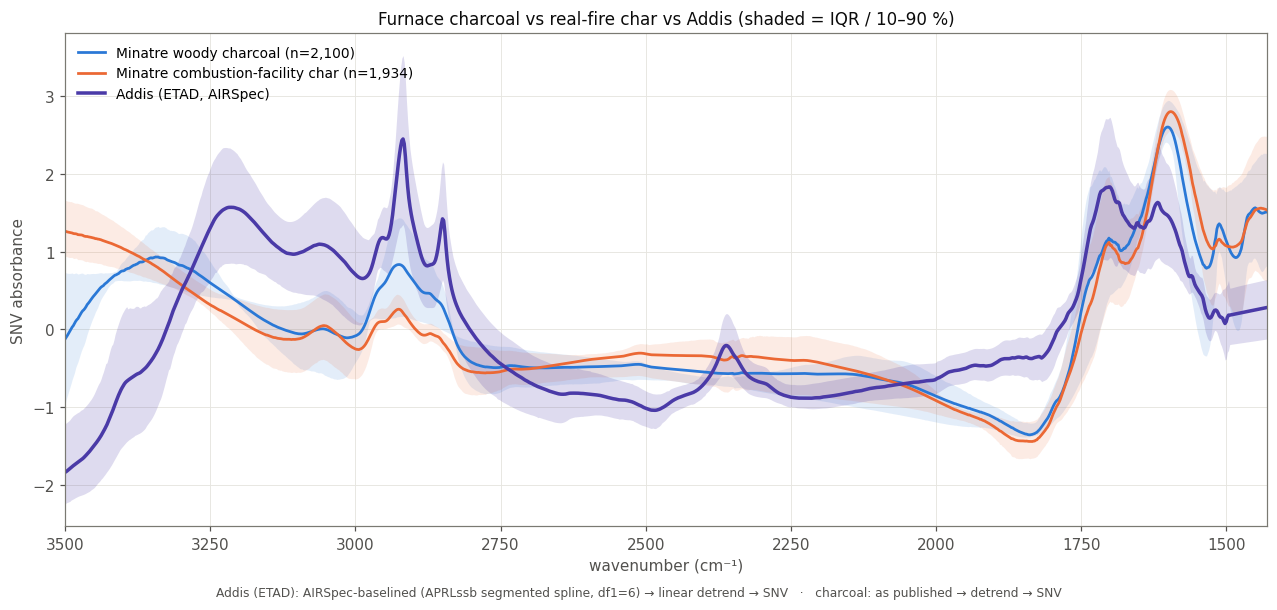

In [6]:
fig, ax = plt.subplots(figsize=(11.5, 5.2), constrained_layout=True)
for name, color in [("Minatre woody charcoal (furnace, 200–800 °C)", SERIES[0]),
                    ("Minatre combustion-facility char (real fires)", SERIES[1])]:
    X = classes[name]
    ax.plot(GRID, X.mean(0), color=color, lw=1.8,
            label=f"{name.split(' (')[0]} (n={len(X):,})")
    q1, q3 = np.percentile(X, [25, 75], axis=0)
    ax.fill_between(GRID, q1, q3, color=color, alpha=0.13, lw=0)
q1, q3 = np.percentile(X_addis, [10, 90], axis=0)
ax.fill_between(GRID, q1, q3, color=ADDIS_COLOR, alpha=0.18, lw=0)
ax.plot(GRID, X_addis.mean(0), color=ADDIS_COLOR, lw=2.3, label="Addis (ETAD, AIRSpec)")
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("SNV absorbance", color=INK2)
ax.set_title("Furnace charcoal vs real-fire char vs Addis (shaded = IQR / 10–90 %)",
             color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig)
fig.savefig(PLOT_DIR / "02_furnace_vs_fire.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view** — the same three series with unit-area scaling instead of SNV, so
the curves read as band intensity. Statistics are unaffected.

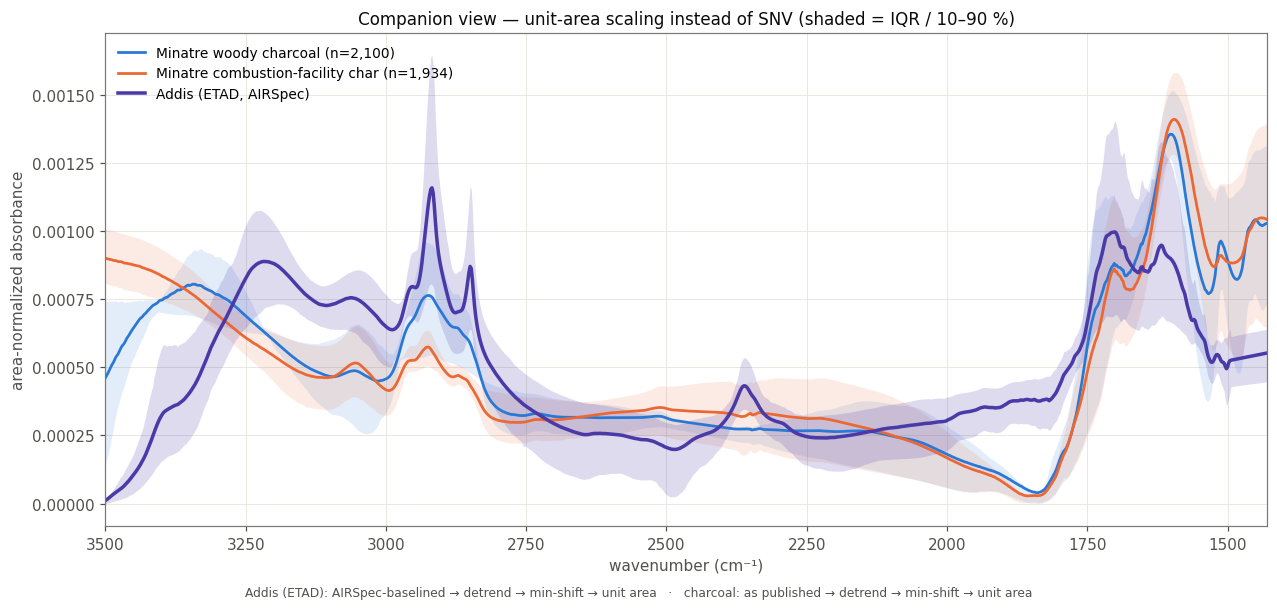

In [7]:
mr_s = prep_s(mr.X, mr.wn)
mb_s = prep_s(mb.X, mb.wn)

fig, ax = plt.subplots(figsize=(11.5, 5.2), constrained_layout=True)
for X, color, name in [(mr_s, SERIES[0], "Minatre woody charcoal"),
                       (mb_s, SERIES[1], "Minatre combustion-facility char")]:
    ax.plot(GRID, X.mean(0), color=color, lw=1.8, label=f"{name} (n={len(X):,})")
    q1, q3 = np.percentile(X, [25, 75], axis=0)
    ax.fill_between(GRID, q1, q3, color=color, alpha=0.13, lw=0)
q1, q3 = np.percentile(X_addis_shape, [10, 90], axis=0)
ax.fill_between(GRID, q1, q3, color=ADDIS_COLOR, alpha=0.18, lw=0)
ax.plot(GRID, X_addis_shape.mean(0), color=ADDIS_COLOR, lw=2.3,
        label="Addis (ETAD, AIRSpec)")
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Companion view — unit-area scaling instead of SNV (shaded = IQR / "
             "10–90 %)", color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig, "Addis (ETAD): AIRSpec-baselined → detrend → min-shift → unit area   ·   "
           "charcoal: as published → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "02b_furnace_vs_fire_shape.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Woody vs herbaceous

McCall is the only collection where one laboratory charred both woody tissue (chestnut
wood, eucalyptus bark, pine bark) and herbaceous material (barley straw, miscanthus,
rice husk) under identical conditions, so it is the only clean test available.

In [8]:
w_best, h_best = best["McCall woody char (ATR)"], best["McCall herbaceous char (ATR)"]
w_mean, h_mean = meanr["McCall woody char (ATR)"], meanr["McCall herbaceous char (ATR)"]
wh = pd.DataFrame({
    "n refs": [len(classes["McCall woody char (ATR)"]),
               len(classes["McCall herbaceous char (ATR)"])],
    "median best r": [np.median(w_best), np.median(h_best)],
    "median mean r": [np.median(w_mean), np.median(h_mean)],
}, index=["woody char", "herbaceous char"]).round(3)
display(wh)
wh.to_csv(TABLE_DIR / "woody_vs_herbaceous.csv")
print(f"paired Wilcoxon on best r : p = {stats.wilcoxon(w_best, h_best).pvalue:.2e}")
print(f"paired Wilcoxon on mean r : p = {stats.wilcoxon(w_mean, h_mean).pvalue:.2e}")
print("\nThe two statistics disagree in direction — herbaceous wins on best r, woody on")
print("mean r — with only 72 references each. No usable woody/herbaceous signal, and the")
print("window excludes the C–O and Si–O regions where the distinction actually lives.")

,n refs,median best r,median mean r
woody char,72,0.430,0.272
herbaceous char,72,0.497,0.258


paired Wilcoxon on best r : p = 2.76e-17
paired Wilcoxon on mean r : p = 4.80e-21

The two statistics disagree in direction — herbaceous wins on best r, woody on
mean r — with only 72 references each. No usable woody/herbaceous signal, and the
window excludes the C–O and Si–O regions where the distinction actually lives.


## 4. Does any of this change the dry-season result?

`char_06` found a distinct spectral type on ~75 % of October–February filters. If that
group were fire-produced char, bringing the combustion-facility reference in should lift
*its* similarity specifically.

,Belg Rainy Season,Dry Season,Kiremt Rainy Season,dry − wet gap
"Minatre woody charcoal (furnace, 200–800 °C)",0.852,0.704,0.791,0.117
Minatre combustion-facility char (real fires),0.680,0.463,0.597,0.176
McCall woody char (ATR),0.564,0.337,0.497,0.194
McCall herbaceous char (ATR),0.634,0.341,0.555,0.254
"Maezumi charcoal (furnace, 200–700 °C)",0.728,0.510,0.657,0.182
Gosling modern charcoal (furnace),0.699,0.482,0.629,0.182
Gosling Ayauchi fossil charcoal,0.672,0.469,0.598,0.166


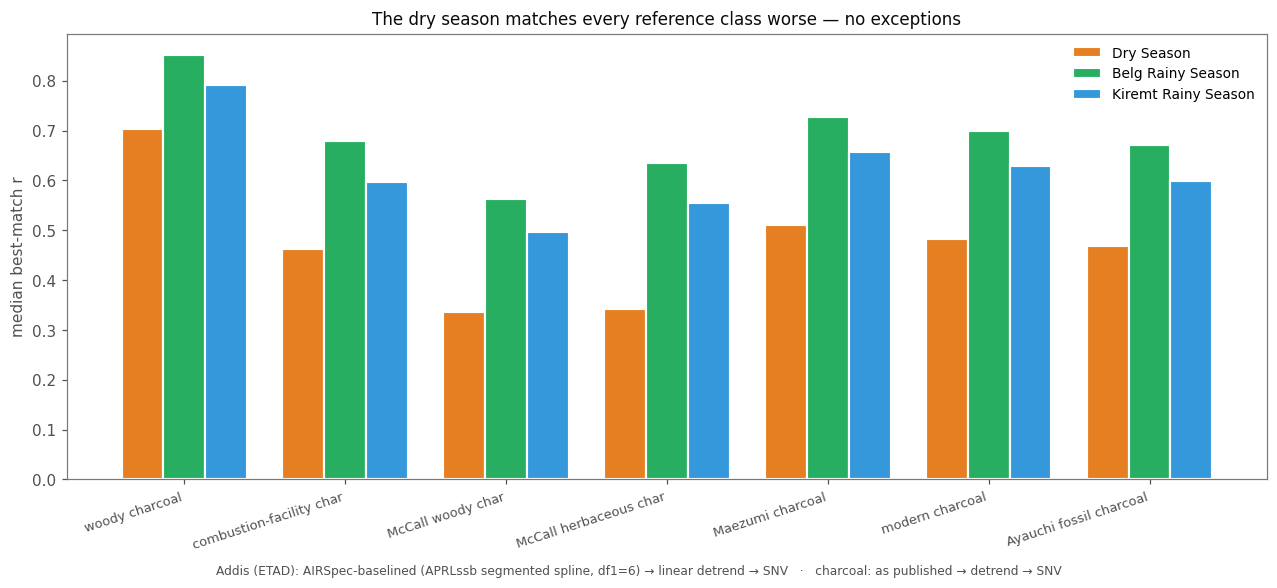

gap between the wet-season mean and the dry season, per class:


,dry − wet gap
McCall herbaceous char (ATR),0.254
McCall woody char (ATR),0.194
"Maezumi charcoal (furnace, 200–700 °C)",0.182
Gosling modern charcoal (furnace),0.182
Minatre combustion-facility char (real fires),0.176
Gosling Ayauchi fossil charcoal,0.166
"Minatre woody charcoal (furnace, 200–800 °C)",0.117


In [9]:
by_season = pd.DataFrame({k: pd.Series(v).groupby(season).median()
                          for k, v in best.items()}).T
by_season["dry − wet gap"] = (
    by_season[["Belg Rainy Season", "Kiremt Rainy Season"]].mean(axis=1)
    - by_season["Dry Season"])
display(by_season.round(3))
by_season.round(4).to_csv(TABLE_DIR / "by_season_by_class.csv")

fig, ax = plt.subplots(figsize=(11.5, 5), constrained_layout=True)
x = np.arange(len(by_season))
width = 0.26
for i, (s, color) in enumerate(SEASON_COLORS.items()):
    ax.bar(x + (i - 1) * width, by_season[s], width, color=color, label=s,
           edgecolor="white", linewidth=1.4)
ax.set_xticks(x)
ax.set_xticklabels([k.split(" (")[0].replace("Minatre ", "").replace("Gosling ", "")
                    for k in by_season.index], rotation=18, ha="right", fontsize=8.5)
ax.set_ylabel("median best-match r", color=INK2)
ax.set_title("The dry season matches every reference class worse — no exceptions",
             color=INK)
ax.legend(fontsize=9)
ax.grid(False)
stamp(fig)
fig.savefig(PLOT_DIR / "03_season_by_class.png", dpi=160, bbox_inches="tight")
plt.show()

print("gap between the wet-season mean and the dry season, per class:")
display(by_season[["dry − wet gap"]].sort_values("dry − wet gap", ascending=False).round(3))

## Takeaways

- **The gap was real and it is now closed.** 1,934 combustion-facility spectra and 31
  Ayauchi fossil spectra had been silently excluded from `char_02` and `char_04` by a
  `temp_c.notna()` filter. Both are now tested. The conclusions of those notebooks do not
  change, but the reason is worth knowing.
- **Fire-produced char is a *worse* Addis analogue than furnace charcoal — decisively.**
  Minatre furnace charcoal matches at median **r = 0.776**; the combustion-facility char
  recovered from real vegetation burns matches at **0.566** (paired Wilcoxon
  p = 1.2×10⁻⁴⁰), and **only 1 of the 239 filters** is better matched by the
  fire-produced material. This is the opposite of what the provenance argument predicts.
- **It is not an artifact, and two controls say so.** The fire char is *not* noisier
  (roughness 0.013 vs 0.014) and is *more* internally coherent (0.816 vs 0.768) — it is a
  tight, well-measured, genuinely different material. And it is not a library-size
  effect: a coverage sweep shows even **25 randomly chosen furnace spectra** beat the
  full 1,934-spectrum burn set, and restricting the furnace set to the burn set's own
  three species (n = 630) leaves the match essentially unchanged at **0.774**.
- **Why this most likely happens** — and it is a caution, not a result. Furnace charcoal
  is a clean carbonization series; combustion-facility char is recovered from real fires,
  where it is partly consumed, ash-contaminated and mixed across burn conditions. The
  furnace set is also a *designed grid* (10 species × 7 temperatures), so it contains
  something close to almost any charring state. Addis matching it better therefore says
  more about the reference library's coverage of composition space than about how the
  Addis material was produced. **"Addis resembles furnace charcoal" is not evidence that
  Addis aerosol was made in a furnace.**
- **Woody vs herbaceous gives no usable signal.** In the one collection that chars both
  under identical conditions, the two statistics contradict each other — herbaceous wins
  on best r (0.497 vs 0.430), woody on mean r (0.272 vs 0.258) — with 72 references each.
  The comparison window also excludes the C–O and Si–O regions where the woody/herbaceous
  distinction actually lives, so this test is underpowered by construction.
- **The dry-season anomaly is not a char-type effect.** Every one of the seven reference
  classes matches dry-season filters worse, with gaps of 0.12–0.25 and no exceptions.
  Bringing in the real-fire reference does not lift the dry-season group specifically, so
  `char_06`'s finding is not "those days are fire-produced char" — whatever that material
  is, it is unlike every kind of charcoal in this archive.

## The limit this notebook cannot cross: charcoal is not soot

All seven reference classes are **char** — carbonized solid fuel. Atmospheric black
carbon at an urban site is largely **soot**: gas-phase-nucleated particles from
incomplete combustion, structurally and chemically distinct from char. The archive
contains no wood-smoke soot, no diesel soot, and no standardized black-carbon reference
material.

That gap is the most plausible reading of the whole folder: Addis filters match char at
r ≈ 0.78 at best, sit at the 96th percentile of the charcoal distance distribution
(`char_02`), and form their own cluster (`char_04`) — all consistent with the dominant
carbonaceous component simply not being in the reference set. **Closing it needs soot
spectra, ideally measured on PTFE filters**, which would also fix the 1430 cm⁻¹ window
limit that every notebook here runs into.